# Partial Dependence Plots

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.datasets import load_diabetes

In [18]:
pd.DataFrame({'Feature 0': ['A1', 'A1', 'A2', 'A2'], 'Feature 1': ['B1', 'B2', 'B3', 'B4'], 'Feature 2': ['C1', 'C2', 'C3', 'C3']})

,Feature 0,Feature 1,Feature 2
0,A1,B1,C1
1,A1,B2,C2
2,A2,B3,C3
3,A2,B4,C3


In [20]:
pd.concat(
    [pd.DataFrame({'Feature 0': ['A1', 'A1', 'A1', 'A1'], 'Feature 1': ['B1', 'B2', 'B3', 'B4'], 'Feature 2': ['C1', 'C2', 'C3', 'C3']}),
     pd.DataFrame({'Feature 0': ['A2', 'A2', 'A2', 'A2'], 'Feature 1': ['B1', 'B2', 'B3', 'B4'], 'Feature 2': ['C1', 'C2', 'C3', 'C3']})]
)

,Feature 0,Feature 1,Feature 2
0,A1,B1,C1
1,A1,B2,C2
2,A1,B3,C3
3,A1,B4,C3
0,A2,B1,C1
1,A2,B2,C2
2,A2,B3,C3
3,A2,B4,C3


In [21]:
pd.concat(
    [pd.DataFrame({'Feature 0': ['A1', 'A1', 'A1', 'A1'], 'Feature 1': ['B1', 'B2', 'B3', 'B4'], 'Feature 2': ['C1', 'C2', 'C3', 'C3'], 'Prediction': ['Y11', 'Y12', 'Y13', 'Y14']}),
     pd.DataFrame({'Feature 0': ['A2', 'A2', 'A2', 'A2'], 'Feature 1': ['B1', 'B2', 'B3', 'B4'], 'Feature 2': ['C1', 'C2', 'C3', 'C3'], 'Prediction': ['Y21', 'Y22', 'Y23', 'Y24']})]
)

,Feature 0,Feature 1,Feature 2,Prediction
0,A1,B1,C1,Y11
1,A1,B2,C2,Y12
2,A1,B3,C3,Y13
3,A1,B4,C3,Y14
0,A2,B1,C1,Y21
1,A2,B2,C2,Y22
2,A2,B3,C3,Y23
3,A2,B4,C3,Y24


In [23]:
pd.DataFrame({'Feature 0': ['A1', 'A2'], 'Prediction': ['AVG(Y11->Y14)', 'AVG(Y21->Y24)']})

,Feature 0,Prediction
0,A1,AVG(Y11->Y14)
1,A2,AVG(Y21->Y24)


Text(0.5, 0, 'Feature Value')

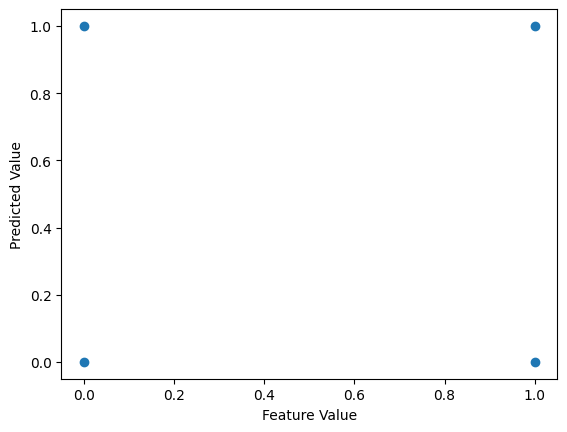

In [30]:
plt.scatter([0, 1, 0, 1], [1, 0, 0, 1])
plt.ylabel('Predicted Value')
plt.xlabel('Feature Value')

Text(0.5, 0, 'Feature Value')

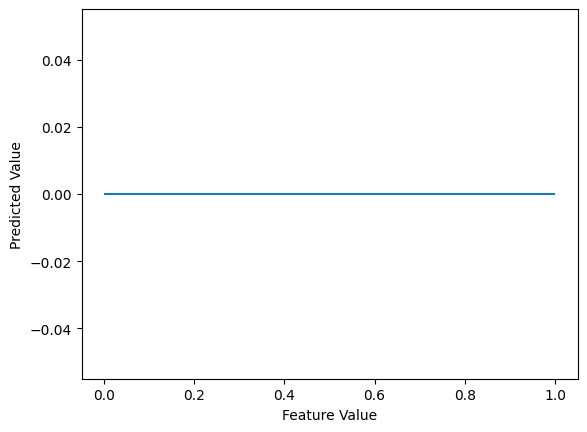

In [33]:
plt.hlines(0, 0, 1)
plt.ylabel('Predicted Value')
plt.xlabel('Feature Value')

## Manual Implementation

In [34]:
from sklearn.ensemble import RandomForestRegressor

In [35]:
X, y = load_diabetes(return_X_y=True)
rf = RandomForestRegressor().fit(X, y)

In [36]:
features = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

features_averages = {}
for feature in tqdm(features):
    features_averages[feature] = ([], [])
    
    for feature_val in np.unique(X[:, feature]):
        features_averages[feature][0].append(feature_val)
        aux_X = np.delete(X, feature, axis=1)
        aux_X = np.hstack((aux_X, np.array([feature_val for i in range(aux_X.shape[0])])[:, None]))
        
        features_averages[feature][1].append(np.mean(rf.predict(aux_X)))

100%|██████████| 10/10 [00:10<00:00,  1.05s/it]


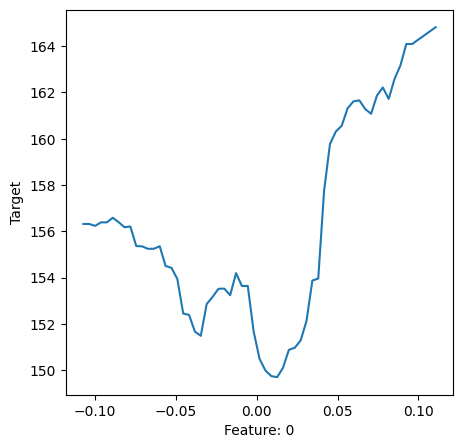

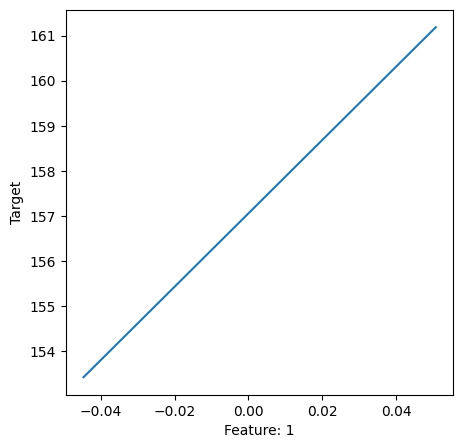

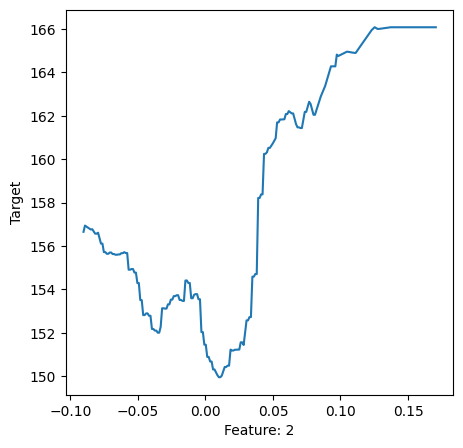

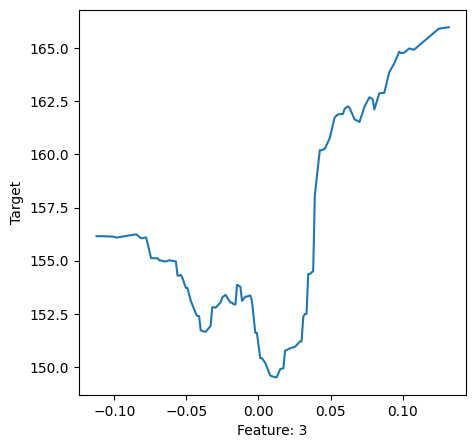

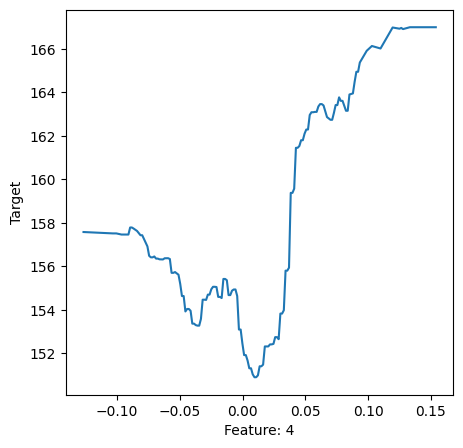

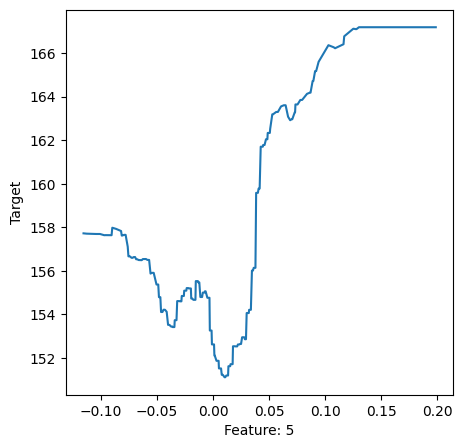

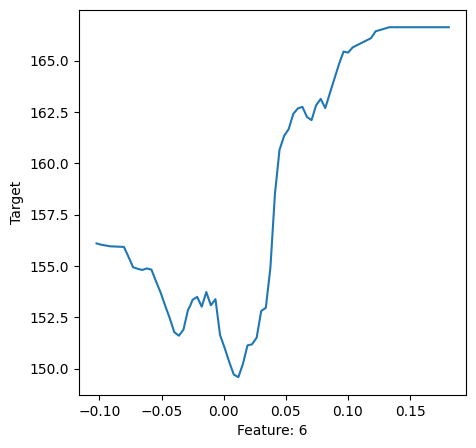

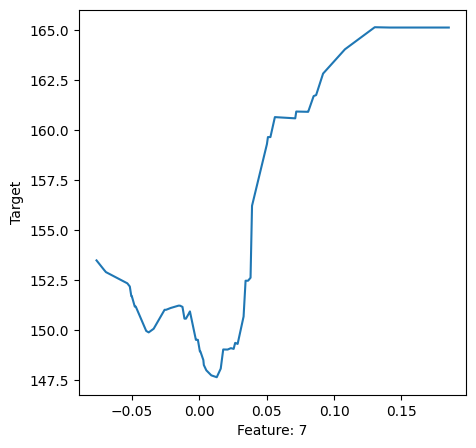

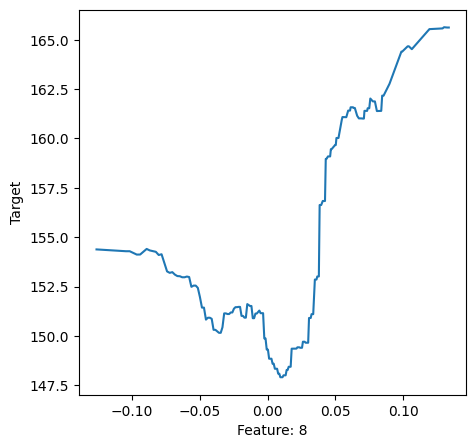

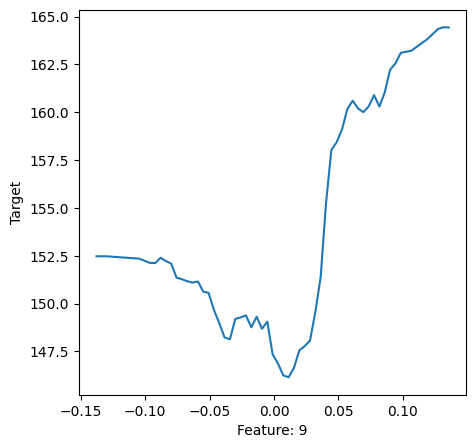

In [37]:
for feature in features_averages:
    plt.figure(figsize=(5,5))
    values = features_averages[feature][0]
    predictions = features_averages[feature][1]
    
    plt.plot(values, predictions)
    plt.xlabel(f'Feature: {feature}')
    plt.ylabel('Target')

## Sklearn Implementation

In [38]:
from sklearn.inspection import PartialDependenceDisplay

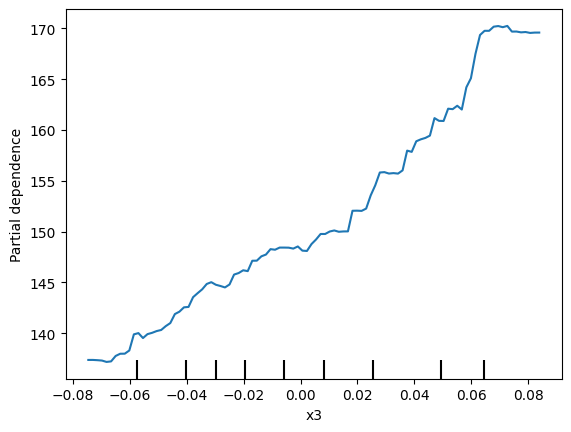

In [41]:
features = [3]
PartialDependenceDisplay.from_estimator(rf, X, features)